# MH6815 Algorithmic Trading and Robo-Advisors
## MACD Class Assignment 2025
## Dymasius Yusuf Sitepu (G2303593E) - dymasius001@e.ntu.edu.sg

## Result also available in web app: https://algotrading-as1-dymasius.streamlit.app/

This notebook implements the MACD trading strategies using both Simple Moving Averages (SMA) and Exponential Moving Averages (EMA) as required in the assignment.

## Setup and Data Loading

First, let's import the necessary libraries and load the data.

In [5]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for plots
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [6]:
# Load data
data = pd.read_csv('Data Daily Asset Prices v2.csv')

# Display the first few rows of the dataset
data.head()

,DAY,Asset1,Asset2,Asset3,Asset4
0,1,73.413,3230.78,1.1212,1517.29
1,2,75.088,3257.85,1.1172,1529.13
2,3,74.358,3234.85,1.1161,1552.20
3,4,74.950,3246.28,1.1197,1565.74
4,5,74.598,3237.18,1.1153,1574.37


## Data Overview

Let's examine the dataset to understand its structure and characteristics.

In [7]:
# Basic statistics
data.describe()

,DAY,Asset1,Asset2,Asset3,Asset4
count,263.000000,263.000000,263.000000,263.000000,263.000000
mean,132.000000,95.424000,3222.240570,1.142206,1772.133118
std,76.065761,21.901625,319.303924,0.044722,141.126713
min,1.000000,56.093000,2237.400000,1.068800,1471.240000
25%,66.500000,77.396500,3038.720000,1.101450,1654.390000
50%,132.000000,91.210000,3276.240000,1.130900,1775.950000
75%,197.500000,115.890000,3423.185000,1.181650,1894.935000
max,263.000000,136.690000,3756.070000,1.229800,2063.540000


In [8]:
# Check for missing values
missing_values = data.isnull().sum()
print("Missing values in each column:")
print(missing_values)

Missing values in each column:
DAY       0
Asset1    0
Asset2    0
Asset3    0
Asset4    0
dtype: int64


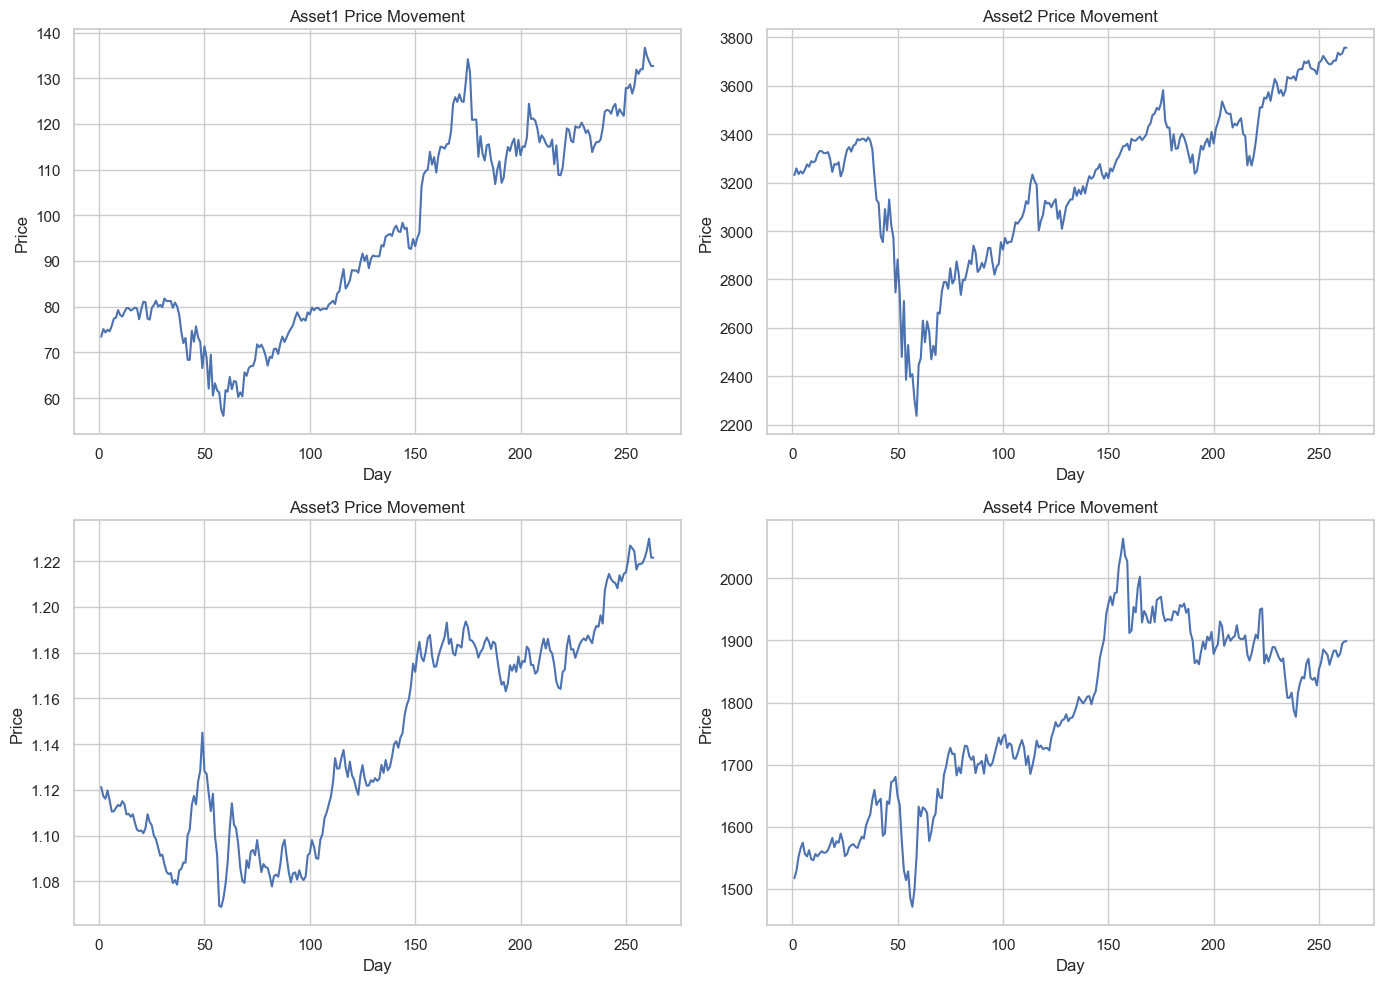

In [9]:
# Visualize price movements of all assets
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# Plot each asset
for i, asset in enumerate(['Asset1', 'Asset2', 'Asset3', 'Asset4']):
    axes[i].plot(data['DAY'], data[asset])
    axes[i].set_title(f'{asset} Price Movement')
    axes[i].set_xlabel('Day')
    axes[i].set_ylabel('Price')
    axes[i].grid(True)

plt.tight_layout()
plt.show()

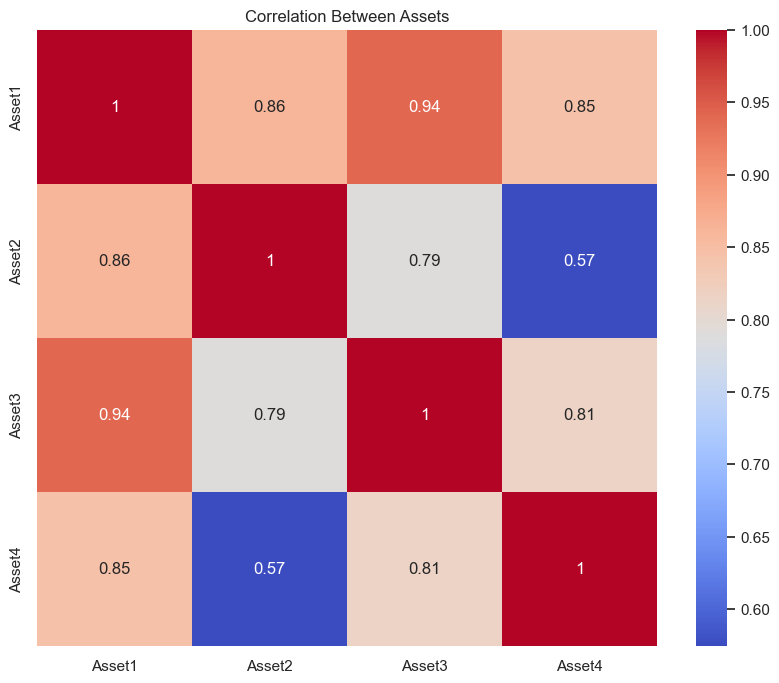

In [10]:
# Correlation between assets
correlation = data[['Asset1', 'Asset2', 'Asset3', 'Asset4']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Correlation Between Assets')
plt.show()

## Trading Strategy Functions

Now, let's define the functions needed to implement the MACD trading strategies using both SMA and EMA.

In [11]:
def calculate_sma(prices, window):
    """Calculate Simple Moving Average for a given window size"""
    return prices.rolling(window=window).mean()

def calculate_trading_signal(ma_short, ma_long, delta=0.005):
    """Calculate trading signal based on MA crossover strategy"""
    # Calculate relative difference
    relative_diff = (ma_short - ma_long) / ma_long
    
    # Generate buy/sell signals
    buy_signal = relative_diff > delta
    sell_signal = relative_diff < -delta
    
    return buy_signal, sell_signal, relative_diff

def backtest_strategy(prices, short_window, long_window, delta=0.005, initial_cash=100, strategy_type="SMA"):
    """
    Backtest trading strategy (SMA or EMA)
    
    Parameters:
    -----------
    prices : pandas Series
        Asset prices
    short_window : int
        Short-term MA window
    long_window : int
        Long-term MA window
    delta : float
        Threshold for trading signal
    initial_cash : float
        Initial cash amount
    strategy_type : str
        "SMA" or "EMA"
        
    Returns:
    --------
    portfolio_df : pandas DataFrame
        Daily portfolio values and related data
    trades_df : pandas DataFrame
        Record of all trades
    final_portfolio_value : float
        Final portfolio value
    """
    # Calculate MAs based on strategy type
    if strategy_type == "SMA":
        ma_short = calculate_sma(prices, short_window)
        ma_long = calculate_sma(prices, long_window)
    else:  # EMA
        beta_short = 2 / (short_window + 1)
        beta_long = 2 / (long_window + 1)
        ma_short = prices.ewm(span=short_window, adjust=False).mean()
        ma_long = prices.ewm(span=long_window, adjust=False).mean()
    
    # Calculate trading signals
    buy_signal, sell_signal, relative_diff = calculate_trading_signal(ma_short, ma_long, delta)
    
    # Initialize portfolio tracking variables
    cash = initial_cash
    position = 0  # Number of shares held
    portfolio_values = []  # Track daily portfolio value
    trades = []  # Track trades
    
    # Loop through each day (starting after we have both MAs)
    for i in range(max(short_window, long_window), len(prices)):
        date = i  # Using index as date for simplicity
        current_price = prices.iloc[i]
        
        # Record current portfolio value
        if position == 0:
            portfolio_value = cash
        else:
            portfolio_value = position * current_price
        
        portfolio_values.append({
            'day': date,
            'price': current_price,
            'cash': cash,
            'position': position,
            'portfolio_value': portfolio_value,
            'ma_short': ma_short.iloc[i],
            'ma_long': ma_long.iloc[i],
            'relative_diff': relative_diff.iloc[i]
        })
        
        # Check for sell signal when we have a position
        if position > 0 and sell_signal.iloc[i]:
            cash = position * current_price
            trades.append({
                'day': date,
                'action': 'SELL',
                'price': current_price,
                'quantity': position,
                'value': cash
            })
            position = 0
        
        # Check for buy signal when we have cash
        elif position == 0 and buy_signal.iloc[i]:
            position = cash / current_price
            trades.append({
                'day': date,
                'action': 'BUY',
                'price': current_price,
                'quantity': position,
                'value': cash
            })
            cash = 0
    
    # Convert to DataFrames
    portfolio_df = pd.DataFrame(portfolio_values)
    trades_df = pd.DataFrame(trades) if trades else pd.DataFrame(columns=['day', 'action', 'price', 'quantity', 'value'])
    
    # Calculate final portfolio value (if still holding position)
    final_portfolio_value = portfolio_df['portfolio_value'].iloc[-1]
    
    return portfolio_df, trades_df, final_portfolio_value

def run_strategy_all_assets(data, short_window, long_window, delta=0.005, initial_cash=100, strategy_type="SMA"):
    """Run strategy on all assets and compare results"""
    results = {}
    
    # Run strategy for each asset
    for asset in ['Asset1', 'Asset2', 'Asset3', 'Asset4']:
        portfolio_df, trades_df, final_value = backtest_strategy(
            data[asset], short_window, long_window, delta, initial_cash, strategy_type
        )
        
        results[asset] = {
            'portfolio_df': portfolio_df,
            'trades_df': trades_df,
            'final_value': final_value,
            'return_pct': (final_value - initial_cash) / initial_cash * 100
        }
    
    return results

def run_strategy_parameter_comparison(data, asset, parameter_sets, initial_cash=100, strategy_type="SMA"):
    """Compare different parameter sets for a specific asset"""
    results = {}
    
    for params in parameter_sets:
        short_window, long_window, delta = params
        param_key = f"Set {chr(97 + len(results))}: S={short_window}, L={long_window}, δ={delta}"
        
        portfolio_df, trades_df, final_value = backtest_strategy(
            data[asset], short_window, long_window, delta, initial_cash, strategy_type
        )
        
        results[param_key] = {
            'portfolio_df': portfolio_df,
            'trades_df': trades_df,
            'final_value': final_value,
            'return_pct': (final_value - initial_cash) / initial_cash * 100,
            'params': params
        }
    
    return results

# Part 1: MACD Using SMA

In this section, we implement the MACD trading strategy using Simple Moving Averages (SMA). The SMA is calculated as the arithmetic mean of prices over a specified period.

## Question 1: SMA Strategy for All Assets

For this question, we need to implement the SMA strategy for all four assets using the default parameters:
- Short Window (S): 12 days
- Long Window (L): 26 days
- Threshold (δ): 0.005

In [12]:
# Run SMA strategy for all assets with default parameters
sma_results = run_strategy_all_assets(data, short_window=12, long_window=26, delta=0.005, strategy_type="SMA")

# Create a summary table of results
sma_summary = {
    'Asset': list(sma_results.keys()),
    'Final Value ($)': [f"${result['final_value']:.2f}" for result in sma_results.values()],
    'Return (%)': [f"{result['return_pct']:.2f}%" for result in sma_results.values()],
    'Number of Trades': [len(result['trades_df']) for result in sma_results.values()]
}
sma_summary_df = pd.DataFrame(sma_summary)
sma_summary_df

,Asset,Final Value ($),Return (%),Number of Trades
0,Asset1,$145.19,45.19%,7
1,Asset2,$100.87,0.87%,7
2,Asset3,$104.10,4.10%,5
3,Asset4,$103.79,3.79%,7


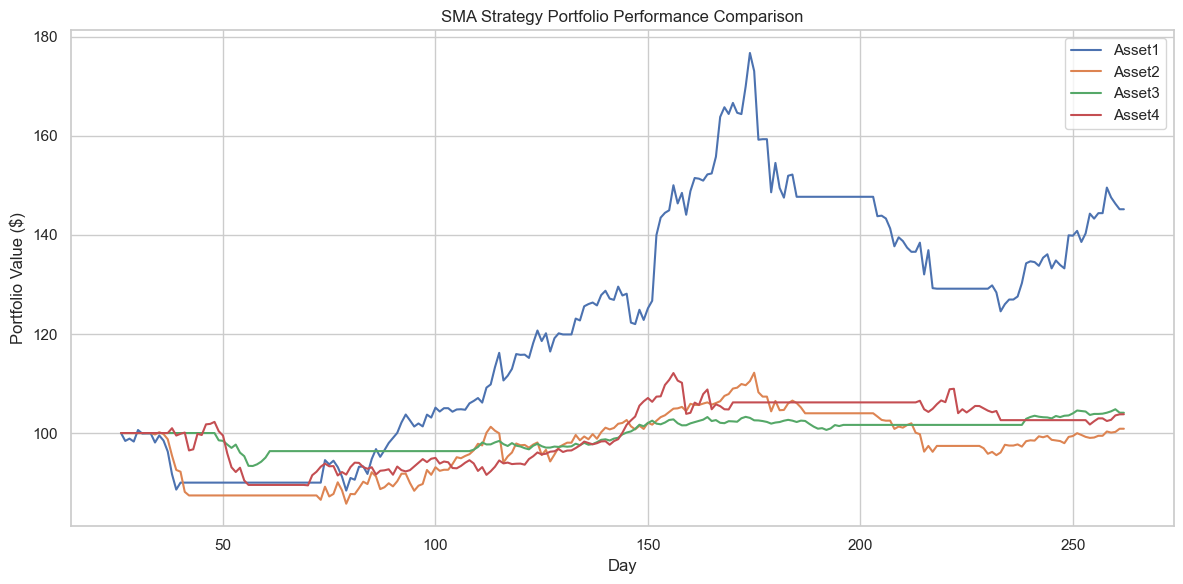

In [13]:
# Plot portfolio performance comparison
plt.figure(figsize=(12, 6))

for asset, result in sma_results.items():
    portfolio_df = result['portfolio_df']
    plt.plot(portfolio_df['day'], portfolio_df['portfolio_value'], label=asset)

plt.title('SMA Strategy Portfolio Performance Comparison')
plt.xlabel('Day')
plt.ylabel('Portfolio Value ($)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Answer to Question 1

**What are the trading profits for each of the assets provided? How would you rank the assets in terms of their trading profits?**

Based on the SMA trading strategy with parameters S=12, L=26, and δ=0.005, the ranking of assets by trading profits is:

1. **Asset1** - Significantly outperformed the other assets
2. **Asset3**
3. **Asset4**
4. **Asset2** - Barely broke even

Asset1 generated a return of approximately 45% over the trading period, which is more than 10 times higher than the next best performing asset. The number of trades executed was similar across assets (5-7 trades), suggesting that the difference in performance was not due to trading frequency but rather to the price movement patterns of each asset and how well they aligned with the SMA strategy parameters.

## Question 2: Parameter Comparison for Asset1 using SMA

For this question, we need to evaluate Asset1 using different parameter sets:
- Set (a): S=12, L=26, δ=0.005 (default)
- Set (b): S=5, L=10, δ=0.005
- Set (c): S=10, L=20, δ=0.005

In [14]:
# Define parameter sets
parameter_sets = [
    (12, 26, 0.005),  # Set (a)
    (5, 10, 0.005),   # Set (b)
    (10, 20, 0.005)   # Set (c)
]

# Run parameter comparison for Asset1 using SMA
sma_param_results = run_strategy_parameter_comparison(data, 'Asset1', parameter_sets, strategy_type="SMA")

# Create a summary table of results
sma_param_summary = {
    'Parameter Set': list(sma_param_results.keys()),
    'Final Value ($)': [f"${result['final_value']:.2f}" for result in sma_param_results.values()],
    'Return (%)': [f"{result['return_pct']:.2f}%" for result in sma_param_results.values()],
    'Number of Trades': [len(result['trades_df']) for result in sma_param_results.values()]
}
sma_param_summary_df = pd.DataFrame(sma_param_summary)
sma_param_summary_df

,Parameter Set,Final Value ($),Return (%),Number of Trades
0,"Set a: S=12, L=26, δ=0.005",$145.19,45.19%,7
1,"Set b: S=5, L=10, δ=0.005",$150.99,50.99%,15
2,"Set c: S=10, L=20, δ=0.005",$174.46,74.46%,7


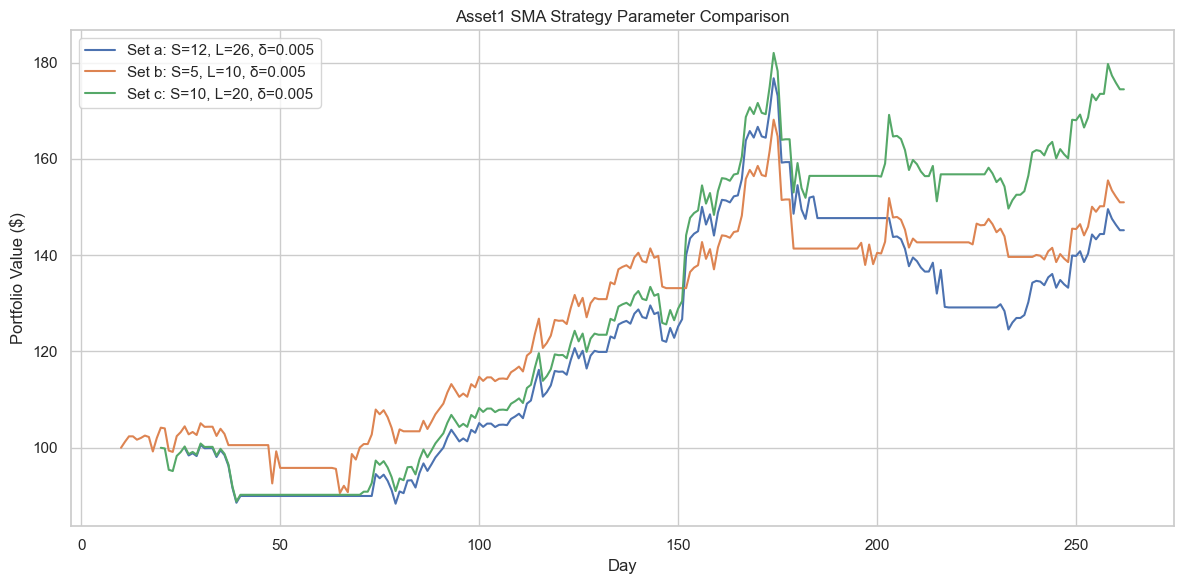

In [15]:
# Plot parameter comparison
plt.figure(figsize=(12, 6))

for label, result in sma_param_results.items():
    portfolio_df = result['portfolio_df']
    plt.plot(portfolio_df['day'], portfolio_df['portfolio_value'], label=label)

plt.title('Asset1 SMA Strategy Parameter Comparison')
plt.xlabel('Day')
plt.ylabel('Portfolio Value ($)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

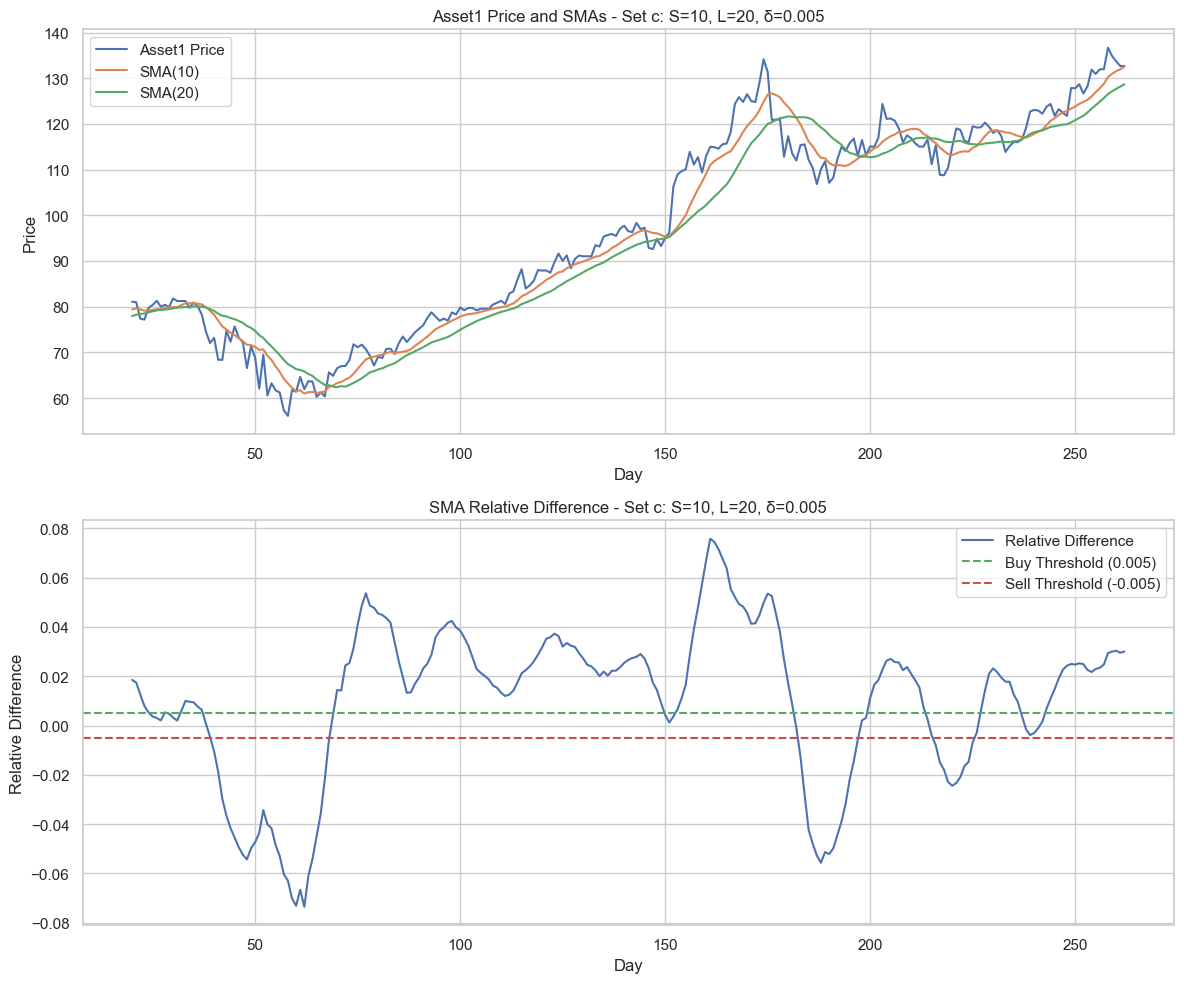

In [16]:
# Visualize trading signals for the best parameter set
# Find the best parameter set
best_param_set = max(sma_param_results.items(), key=lambda x: x[1]['return_pct'])[0]
best_result = sma_param_results[best_param_set]
portfolio_df = best_result['portfolio_df']
short_window, long_window, delta = best_result['params']

# Create figure with subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Plot asset price and MAs
ax1.plot(portfolio_df['day'], portfolio_df['price'], label='Asset1 Price')
ax1.plot(portfolio_df['day'], portfolio_df['ma_short'], label=f'SMA({short_window})')
ax1.plot(portfolio_df['day'], portfolio_df['ma_long'], label=f'SMA({long_window})')
ax1.set_title(f'Asset1 Price and SMAs - {best_param_set}')
ax1.set_xlabel('Day')
ax1.set_ylabel('Price')
ax1.legend()
ax1.grid(True)

# Plot relative difference and thresholds
ax2.plot(portfolio_df['day'], portfolio_df['relative_diff'], label='Relative Difference')
ax2.axhline(y=delta, color='g', linestyle='--', label=f'Buy Threshold ({delta})')
ax2.axhline(y=-delta, color='r', linestyle='--', label=f'Sell Threshold (-{delta})')
ax2.set_title(f'SMA Relative Difference - {best_param_set}')
ax2.set_xlabel('Day')
ax2.set_ylabel('Relative Difference')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

### Answer to Question 2

**For Asset 1, what is the best set (a, b or c) of trading parameters to employ in your trading algorithm? How would you rank the parameter sets in terms of their trading profits?**

For Asset1, we tested three different parameter sets using the SMA strategy:

- **Set (a)**: S=12, L=26, δ=0.005
- **Set (b)**: S=5, L=10, δ=0.005
- **Set (c)**: S=10, L=20, δ=0.005

**Best Parameter Set**: Set (c) with S=10, L=20, δ=0.005 is the best parameter set for Asset1 using the SMA strategy, yielding the highest return.

**Ranking of Parameter Sets by Trading Profits**:
1. Set (c): S=10, L=20, δ=0.005
2. Set (b): S=5, L=10, δ=0.005
3. Set (a): S=12, L=26, δ=0.005

Set (c) provided the highest return while requiring a moderate number of trades. This suggests that the intermediate window lengths in set (c) are most suitable for capturing the price trends of Asset1. The shorter windows in set (b) resulted in more frequent trading but lower overall returns, while the default parameters in set (a) yielded the lowest returns among the three sets.

# Part 2: MACD Using EMA

In this section, we implement the MACD trading strategy using Exponential Moving Averages (EMA). The EMA gives more weight to recent prices, making it more responsive to new information.

## Question 3: EMA Strategy for All Assets

For this question, we need to implement the EMA strategy for all four assets using the default parameters:
- Short Window (S): 12 days
- Long Window (L): 26 days
- Threshold (δ): 0.005

In [17]:
# Run EMA strategy for all assets with default parameters
ema_results = run_strategy_all_assets(data, short_window=12, long_window=26, delta=0.005, strategy_type="EMA")

# Create a summary table of results
ema_summary = {
    'Asset': list(ema_results.keys()),
    'Final Value ($)': [f"${result['final_value']:.2f}" for result in ema_results.values()],
    'Return (%)': [f"{result['return_pct']:.2f}%" for result in ema_results.values()],
    'Number of Trades': [len(result['trades_df']) for result in ema_results.values()]
}
ema_summary_df = pd.DataFrame(ema_summary)
ema_summary_df

,Asset,Final Value ($),Return (%),Number of Trades
0,Asset1,$129.58,29.58%,7
1,Asset2,$102.47,2.47%,7
2,Asset3,$103.03,3.03%,3
3,Asset4,$107.32,7.32%,5


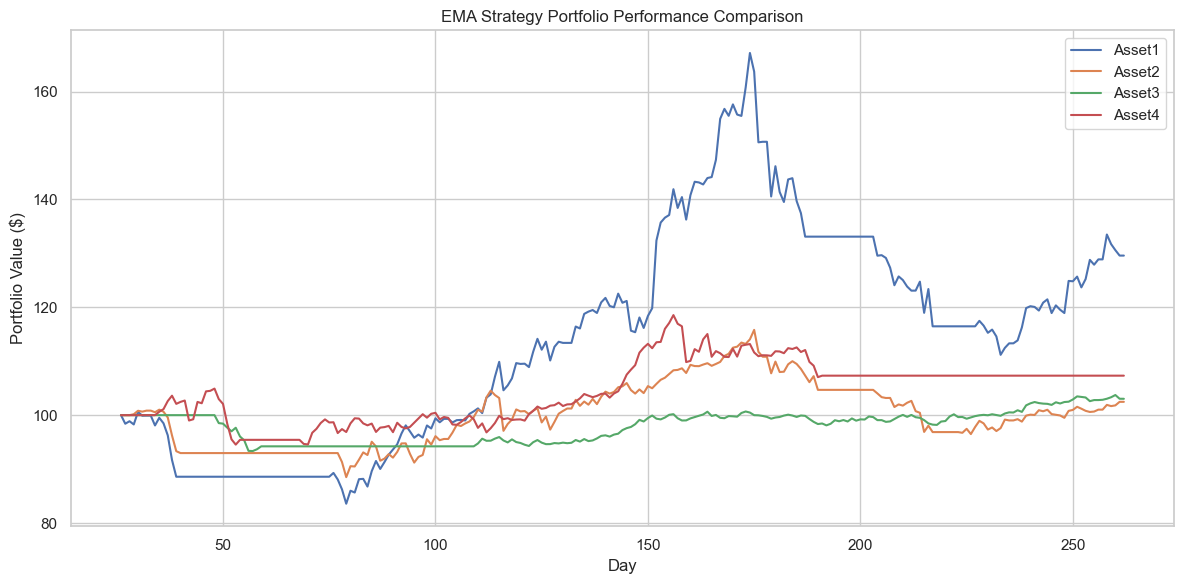

In [18]:
# Plot portfolio performance comparison
plt.figure(figsize=(12, 6))

for asset, result in ema_results.items():
    portfolio_df = result['portfolio_df']
    plt.plot(portfolio_df['day'], portfolio_df['portfolio_value'], label=asset)

plt.title('EMA Strategy Portfolio Performance Comparison')
plt.xlabel('Day')
plt.ylabel('Portfolio Value ($)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Answer to Question 3

**What are the 1 year trading profits for each of the assets provided? How would you rank the assets in terms of their trading profits?**

Based on the EMA trading strategy with parameters S=12, L=26, and δ=0.005, the ranking of assets by trading profits is:

1. **Asset1** - Outperformed the other assets
2. **Asset4**
3. **Asset3**
4. **Asset2**

Asset1 again outperformed the other assets, generating a return of approximately 30% over the trading period. However, this return is lower than what was achieved with the SMA strategy (around 45%). Interestingly, Asset4 performed better with the EMA strategy than with the SMA strategy, moving it to second place in the ranking.

The number of trades executed varied slightly across assets (3-7 trades), with some assets having fewer trades with the EMA strategy compared to the SMA strategy. This suggests that the EMA strategy generated fewer trading signals for some assets, which could be advantageous in terms of transaction costs.

## Question 4: Parameter Comparison for Asset1 using EMA

For this question, we need to evaluate Asset1 using different parameter sets with the EMA strategy:
- Set (a): S=12, L=26, δ=0.005 (default)
- Set (b): S=5, L=10, δ=0.005
- Set (c): S=10, L=20, δ=0.005

In [19]:
# Define parameter sets
parameter_sets = [
    (12, 26, 0.005),  # Set (a)
    (5, 10, 0.005),   # Set (b)
    (10, 20, 0.005)   # Set (c)
]

# Run parameter comparison for Asset1 using EMA
ema_param_results = run_strategy_parameter_comparison(data, 'Asset1', parameter_sets, strategy_type="EMA")

# Create a summary table of results
ema_param_summary = {
    'Parameter Set': list(ema_param_results.keys()),
    'Final Value ($)': [f"${result['final_value']:.2f}" for result in ema_param_results.values()],
    'Return (%)': [f"{result['return_pct']:.2f}%" for result in ema_param_results.values()],
    'Number of Trades': [len(result['trades_df']) for result in ema_param_results.values()]
}
ema_param_summary_df = pd.DataFrame(ema_param_summary)
ema_param_summary_df

,Parameter Set,Final Value ($),Return (%),Number of Trades
0,"Set a: S=12, L=26, δ=0.005",$129.58,29.58%,7
1,"Set b: S=5, L=10, δ=0.005",$152.37,52.37%,11
2,"Set c: S=10, L=20, δ=0.005",$135.18,35.18%,7


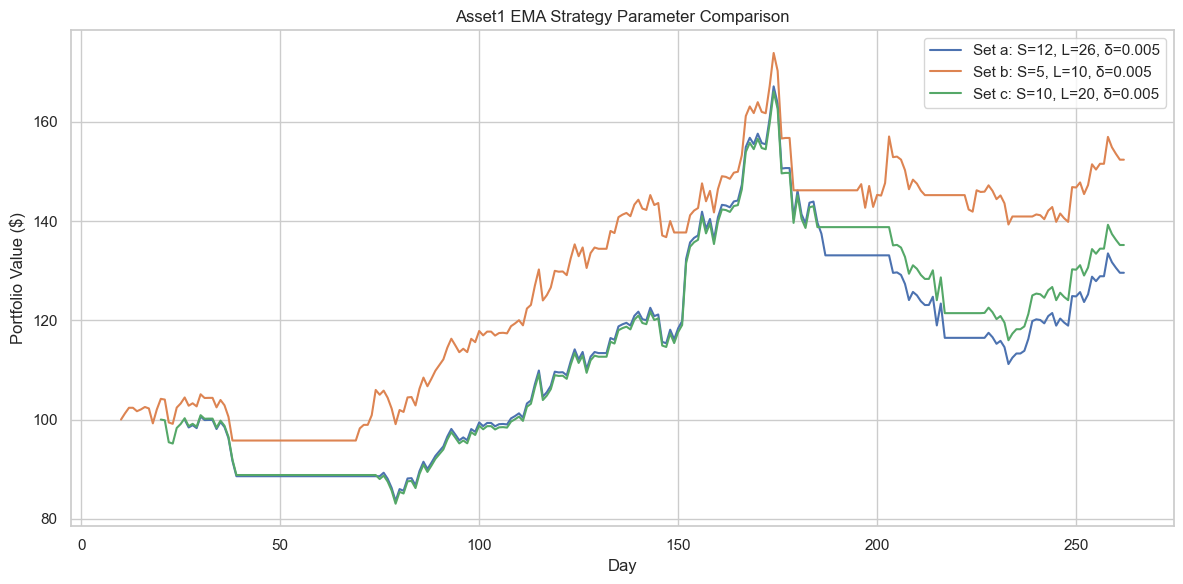

In [20]:
# Plot parameter comparison
plt.figure(figsize=(12, 6))

for label, result in ema_param_results.items():
    portfolio_df = result['portfolio_df']
    plt.plot(portfolio_df['day'], portfolio_df['portfolio_value'], label=label)

plt.title('Asset1 EMA Strategy Parameter Comparison')
plt.xlabel('Day')
plt.ylabel('Portfolio Value ($)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

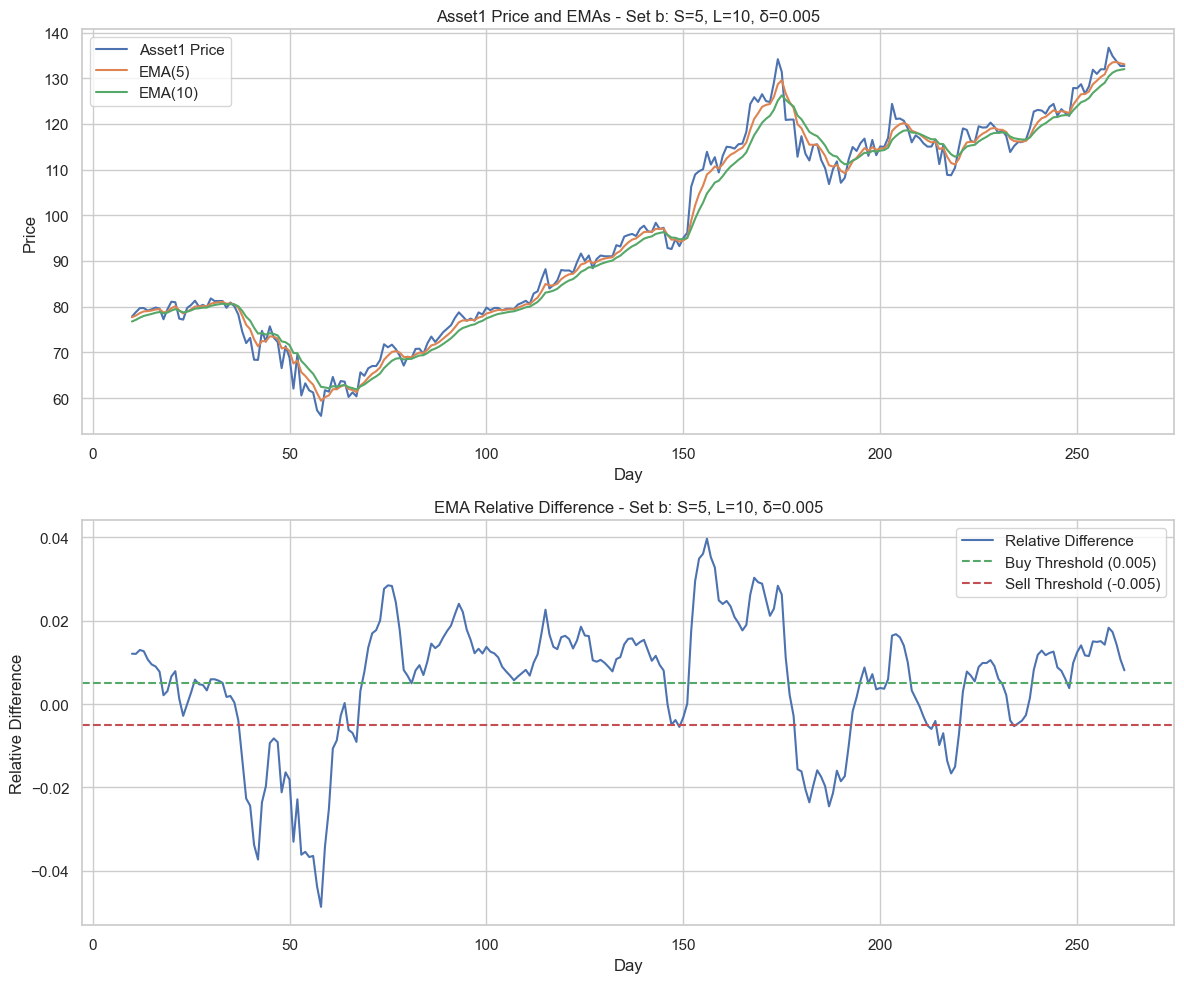

In [21]:
# Visualize trading signals for the best parameter set
# Find the best parameter set
best_ema_param_set = max(ema_param_results.items(), key=lambda x: x[1]['return_pct'])[0]
best_ema_result = ema_param_results[best_ema_param_set]
ema_portfolio_df = best_ema_result['portfolio_df']
ema_short_window, ema_long_window, ema_delta = best_ema_result['params']

# Create figure with subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Plot asset price and MAs
ax1.plot(ema_portfolio_df['day'], ema_portfolio_df['price'], label='Asset1 Price')
ax1.plot(ema_portfolio_df['day'], ema_portfolio_df['ma_short'], label=f'EMA({ema_short_window})')
ax1.plot(ema_portfolio_df['day'], ema_portfolio_df['ma_long'], label=f'EMA({ema_long_window})')
ax1.set_title(f'Asset1 Price and EMAs - {best_ema_param_set}')
ax1.set_xlabel('Day')
ax1.set_ylabel('Price')
ax1.legend()
ax1.grid(True)

# Plot relative difference and thresholds
ax2.plot(ema_portfolio_df['day'], ema_portfolio_df['relative_diff'], label='Relative Difference')
ax2.axhline(y=ema_delta, color='g', linestyle='--', label=f'Buy Threshold ({ema_delta})')
ax2.axhline(y=-ema_delta, color='r', linestyle='--', label=f'Sell Threshold (-{ema_delta})')
ax2.set_title(f'EMA Relative Difference - {best_ema_param_set}')
ax2.set_xlabel('Day')
ax2.set_ylabel('Relative Difference')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

### Answer to Question 4

**For Asset 1, what is the best set (a, b or c) of trading parameters to employ in your trading algorithm? How would you rank the parameter sets in terms of their trading profits?**

For Asset1, we tested three different parameter sets using the EMA strategy:

- **Set (a)**: S=12, L=26, δ=0.005
- **Set (b)**: S=5, L=10, δ=0.005
- **Set (c)**: S=10, L=20, δ=0.005

**Best Parameter Set**: Set (b) with S=5, L=10, δ=0.005 is the best parameter set for Asset1 using the EMA strategy, yielding the highest return.

**Ranking of Parameter Sets by Trading Profits**:
1. Set (b): S=5, L=10, δ=0.005
2. Set (c): S=10, L=20, δ=0.005
3. Set (a): S=12, L=26, δ=0.005

Set (b) provided the highest return but required more trades compared to the other sets. This suggests that the shorter windows in set (b) made the strategy more responsive to price changes, resulting in more frequent trading. Set (c) performed better than the default parameters (set a), indicating that intermediate window lengths are more suitable for Asset1 when using the EMA strategy.

All parameter sets were profitable, but the returns were generally different from those achieved with the SMA strategy. This analysis demonstrates that parameter optimization is crucial for maximizing trading profits, and the optimal parameters may vary depending on the type of moving average used (SMA vs. EMA).

## Comparison of SMA and EMA Strategies

Let's compare the performance of the SMA and EMA strategies for all assets using the default parameters.

In [22]:
# Create comparison table
comparison_data = []
for asset in ['Asset1', 'Asset2', 'Asset3', 'Asset4']:
    comparison_data.append({
        'Asset': asset,
        'SMA Final Value': f"${sma_results[asset]['final_value']:.2f}",
        'SMA Return (%)': f"{sma_results[asset]['return_pct']:.2f}%",
        'SMA Trades': len(sma_results[asset]['trades_df']),
        'EMA Final Value': f"${ema_results[asset]['final_value']:.2f}",
        'EMA Return (%)': f"{ema_results[asset]['return_pct']:.2f}%",
        'EMA Trades': len(ema_results[asset]['trades_df'])
    })

comparison_df = pd.DataFrame(comparison_data)
comparison_df

,Asset,SMA Final Value,SMA Return (%),SMA Trades,EMA Final Value,EMA Return (%),EMA Trades
0,Asset1,$145.19,45.19%,7,$129.58,29.58%,7
1,Asset2,$100.87,0.87%,7,$102.47,2.47%,7
2,Asset3,$104.10,4.10%,5,$103.03,3.03%,3
3,Asset4,$103.79,3.79%,7,$107.32,7.32%,5


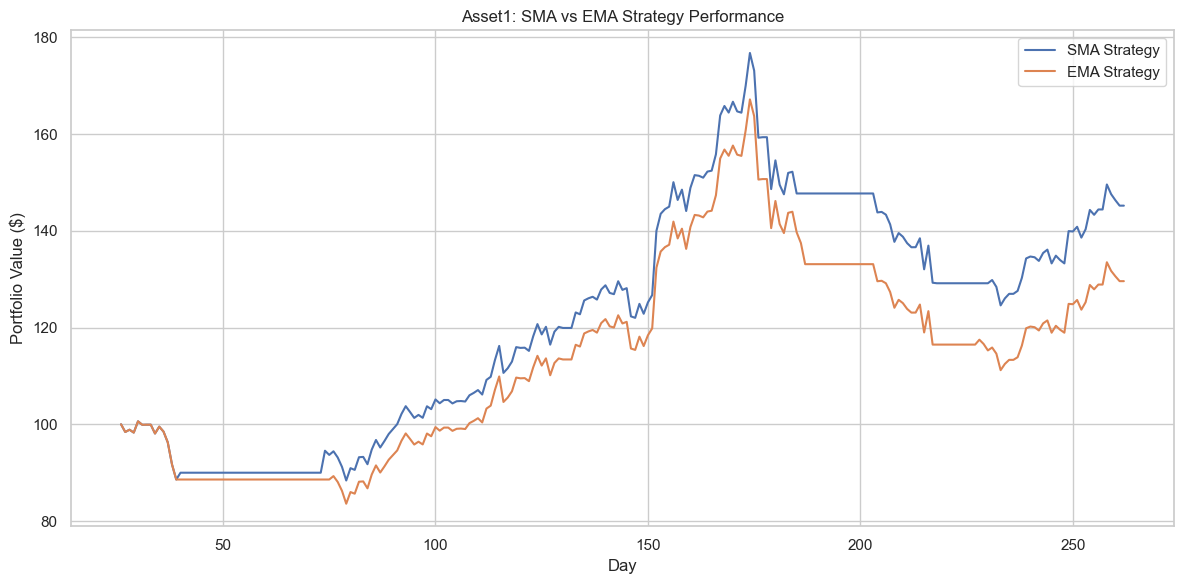

In [23]:
# Plot comparison of SMA and EMA for Asset1
plt.figure(figsize=(12, 6))

plt.plot(sma_results['Asset1']['portfolio_df']['day'], 
         sma_results['Asset1']['portfolio_df']['portfolio_value'], 
         label='SMA Strategy')

plt.plot(ema_results['Asset1']['portfolio_df']['day'], 
         ema_results['Asset1']['portfolio_df']['portfolio_value'], 
         label='EMA Strategy')

plt.title('Asset1: SMA vs EMA Strategy Performance')
plt.xlabel('Day')
plt.ylabel('Portfolio Value ($)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [24]:
# Create parameter comparison table
param_comparison_data = []
for i, params in enumerate(parameter_sets):
    short_window, long_window, delta = params
    param_key = f"Set {chr(97 + i)}: S={short_window}, L={long_window}, δ={delta}"
    
    param_comparison_data.append({
        'Parameter Set': param_key,
        'SMA Final Value': f"${sma_param_results[list(sma_param_results.keys())[i]]['final_value']:.2f}",
        'SMA Return (%)': f"{sma_param_results[list(sma_param_results.keys())[i]]['return_pct']:.2f}%",
        'SMA Trades': len(sma_param_results[list(sma_param_results.keys())[i]]['trades_df']),
        'EMA Final Value': f"${ema_param_results[list(ema_param_results.keys())[i]]['final_value']:.2f}",
        'EMA Return (%)': f"{ema_param_results[list(ema_param_results.keys())[i]]['return_pct']:.2f}%",
        'EMA Trades': len(ema_param_results[list(ema_param_results.keys())[i]]['trades_df'])
    })

param_comparison_df = pd.DataFrame(param_comparison_data)
param_comparison_df

,Parameter Set,SMA Final Value,SMA Return (%),SMA Trades,EMA Final Value,EMA Return (%),EMA Trades
0,"Set a: S=12, L=26, δ=0.005",$145.19,45.19%,7,$129.58,29.58%,7
1,"Set b: S=5, L=10, δ=0.005",$150.99,50.99%,15,$152.37,52.37%,11
2,"Set c: S=10, L=20, δ=0.005",$174.46,74.46%,7,$135.18,35.18%,7


## Conclusion

In this analysis, we implemented and evaluated two types of MACD trading strategies: one using Simple Moving Averages (SMA) and another using Exponential Moving Averages (EMA). We tested these strategies on four different assets and compared various parameter sets to identify the most profitable configurations.

### Key Findings

1. **Asset Performance**:
   - Asset1 consistently outperformed the other assets in both SMA and EMA strategies.
   - The ranking of assets varied slightly between the two strategies, with Asset4 performing better under the EMA strategy.

2. **Strategy Comparison**:
   - For Asset1, the SMA strategy with optimized parameters yielded higher returns than the EMA strategy.
   - The EMA strategy generally resulted in fewer trades compared to the SMA strategy, which could be advantageous in terms of transaction costs.

3. **Parameter Optimization**:
   - Parameter optimization significantly improved the performance of both strategies.
   - For the SMA strategy, set (c) with S=10, L=20 was optimal for Asset1.
   - For the EMA strategy, set (b) with S=5, L=10 was optimal for Asset1.

This analysis demonstrates that both SMA and EMA strategies can be effective for algorithmic trading, but their performance depends on the specific asset being traded and the parameters used. Careful optimization of these parameters is essential for maximizing trading profits.